<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearning/blob/master/DeepLearning/7_1_Live_Class_Notebook_Tensorflow_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [ ]:
# Load the IMDB dataset (pre-tokenized by Keras)
# num_words=10000 means: only keep the 10,000 most frequent words

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 32

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples: {len(X_train_raw)}")
print(f"Test samples:     {len(X_test_raw)}")
print(f"Labels: 0 = Negative, 1 = Positive")
print(f"\nLabel distribution (train): {np.bincount(y_train)}")
print(f"Label distribution (test):  {np.bincount(y_test)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Test samples:     25000
Labels: 0 = Negative, 1 = Positive

Label distribution (train): [12500 12500]
Label distribution (test):  [12500 12500]


In [ ]:
num_words = [len(i) for i in X_train_raw]


In [ ]:
num_words[:5]

[218, 189, 141, 550, 147]

In [ ]:
np.max(num_words)

np.int64(2494)

In [ ]:
print("mean: ", np.mean(num_words))
print("98th percentile: ", np.percentile(num_words, 98))
print("80th percentile: ", np.percentile(num_words, 80))

mean:  238.71364
98th percentile:  799.0200000000004
80th percentile:  331.0


In [ ]:
# 98th 50k x 800

# Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Some sample movie reviews
sample_reviews = [
    "This movie was absolutely fantastic",
    "Terrible movie, waste of time",
    "The acting was fantastic and the plot was great",
    "I hated this movie so much",
    "A great movie with a wonderful story",
    "Worst movie I have ever seen",
]


# Create a tokenizer
tokenizer = Tokenizer()


# Build the vocabulary from our texts
tokenizer.fit_on_texts(sample_reviews)


# Let's see the vocabulary (word -> index mapping)
print("Vocabulary (word → index):")
print("-" * 35)
for word, index in sorted(tokenizer.word_index.items(), key=lambda x: x[1]):
    print(f"  '{word}' → {index}")

Vocabulary (word → index):
-----------------------------------
  'movie' → 1
  'was' → 2
  'this' → 3
  'fantastic' → 4
  'the' → 5
  'great' → 6
  'i' → 7
  'a' → 8
  'absolutely' → 9
  'terrible' → 10
  'waste' → 11
  'of' → 12
  'time' → 13
  'acting' → 14
  'and' → 15
  'plot' → 16
  'hated' → 17
  'so' → 18
  'much' → 19
  'with' → 20
  'wonderful' → 21
  'story' → 22
  'worst' → 23
  'have' → 24
  'ever' → 25
  'seen' → 26


In [ ]:
print(f"\nVocabulary size: {len(tokenizer.word_index)} unique words")


Vocabulary size: 26 unique words


In [ ]:
sample_reviews

['This movie was absolutely fantastic',
 'Terrible movie, waste of time',
 'The acting was fantastic and the plot was great',
 'I hated this movie so much',
 'A great movie with a wonderful story',
 'Worst movie I have ever seen']

In [ ]:
# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(sample_reviews)

print("Text → Sequence conversion:")
print("=" * 60)
for text, seq in zip(sample_reviews, sequences):
    print(f"\n  Text:     \"{text}\"")
    print(f"  Sequence: {seq}")

Text → Sequence conversion:

  Text:     "This movie was absolutely fantastic"
  Sequence: [3, 1, 2, 9, 4]

  Text:     "Terrible movie, waste of time"
  Sequence: [10, 1, 11, 12, 13]

  Text:     "The acting was fantastic and the plot was great"
  Sequence: [5, 14, 2, 4, 15, 5, 16, 2, 6]

  Text:     "I hated this movie so much"
  Sequence: [7, 17, 3, 1, 18, 19]

  Text:     "A great movie with a wonderful story"
  Sequence: [8, 6, 1, 20, 8, 21, 22]

  Text:     "Worst movie I have ever seen"
  Sequence: [23, 1, 7, 24, 25, 26]


# Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Show the problem: sequences have different lengths
print("Sequence lengths before padding:")
for i, seq in enumerate(sequences):
    print(f"  Review {i+1}: length {len(seq)} → {seq}")

print("\n" + "=" * 60)

Sequence lengths before padding:
  Review 1: length 5 → [3, 1, 2, 9, 4]
  Review 2: length 5 → [10, 1, 11, 12, 13]
  Review 3: length 9 → [5, 14, 2, 4, 15, 5, 16, 2, 6]
  Review 4: length 6 → [7, 17, 3, 1, 18, 19]
  Review 5: length 7 → [8, 6, 1, 20, 8, 21, 22]
  Review 6: length 6 → [23, 1, 7, 24, 25, 26]



In [ ]:
# padded = pad_sequences(sequences, maxlen=8, padding='pre')

# print("\nAfter padding (maxlen=8, padding='pre'):")
# for i, (seq, pad) in enumerate(zip(sequences, padded)):
#     print(f"  Review {i+1}: {list(pad)}")

# print(f"\nShape: {padded.shape}  →  ({padded.shape[0]} reviews, {padded.shape[1]} tokens each)")


After padding (maxlen=8, padding='pre'):
  Review 1: [np.int32(0), np.int32(0), np.int32(0), np.int32(3), np.int32(1), np.int32(2), np.int32(9), np.int32(4)]
  Review 2: [np.int32(0), np.int32(0), np.int32(0), np.int32(10), np.int32(1), np.int32(11), np.int32(12), np.int32(13)]
  Review 3: [np.int32(14), np.int32(2), np.int32(4), np.int32(15), np.int32(5), np.int32(16), np.int32(2), np.int32(6)]
  Review 4: [np.int32(0), np.int32(0), np.int32(7), np.int32(17), np.int32(3), np.int32(1), np.int32(18), np.int32(19)]
  Review 5: [np.int32(0), np.int32(8), np.int32(6), np.int32(1), np.int32(20), np.int32(8), np.int32(21), np.int32(22)]
  Review 6: [np.int32(0), np.int32(0), np.int32(23), np.int32(1), np.int32(7), np.int32(24), np.int32(25), np.int32(26)]

Shape: (6, 8)  →  (6 reviews, 8 tokens each)


In [ ]:
padded = pad_sequences(sequences, maxlen=8, padding='post')

print("\nAfter padding (maxlen=8, padding='post'):")
for i, (seq, pad) in enumerate(zip(sequences, padded)):
    print(f"  Review {i+1}: {list(pad)}")

print(f"\nShape: {padded.shape}  →  ({padded.shape[0]} reviews, {padded.shape[1]} tokens each)")


After padding (maxlen=8, padding='post'):
  Review 1: [np.int32(3), np.int32(1), np.int32(2), np.int32(9), np.int32(4), np.int32(0), np.int32(0), np.int32(0)]
  Review 2: [np.int32(10), np.int32(1), np.int32(11), np.int32(12), np.int32(13), np.int32(0), np.int32(0), np.int32(0)]
  Review 3: [np.int32(14), np.int32(2), np.int32(4), np.int32(15), np.int32(5), np.int32(16), np.int32(2), np.int32(6)]
  Review 4: [np.int32(7), np.int32(17), np.int32(3), np.int32(1), np.int32(18), np.int32(19), np.int32(0), np.int32(0)]
  Review 5: [np.int32(8), np.int32(6), np.int32(1), np.int32(20), np.int32(8), np.int32(21), np.int32(22), np.int32(0)]
  Review 6: [np.int32(23), np.int32(1), np.int32(7), np.int32(24), np.int32(25), np.int32(26), np.int32(0), np.int32(0)]

Shape: (6, 8)  →  (6 reviews, 8 tokens each)


# Embedding Layer

In [ ]:
# Let's see exactly what an embedding layer does

vocab_size = len(tokenizer.word_index) + 1  # +1 because index 0 is reserved for padding
embedding_dim = 10  # Each word will be represented by a 4-dimensional vector


print(f"Vocabulary size: {vocab_size} (including padding token at index 0)")
print(f"Embedding dimension: {embedding_dim}")
print(f"Embedding matrix shape: ({vocab_size}, {embedding_dim})")
print()


# Create an embedding layer
embedding_layer = keras.layers.Embedding(
    input_dim=vocab_size,     # How many words in our vocabulary
    output_dim=embedding_dim  # How many dimensions per word vector
)


# Pass a single sequence through the embedding layer
sample_input = tf.constant([[1, 3, 5, 0]])  # "movie", "fantastic", "of", <PAD>
embedded = embedding_layer(sample_input)

print(f"Input shape:  {sample_input.shape}  →  (1 sentence, 4 tokens)")
print(f"Output shape: {embedded.shape}  →  (1 sentence, 4 tokens, {embedding_dim}-dim vector each)")
print()
print("Each token is now a vector:")

Vocabulary size: 27 (including padding token at index 0)
Embedding dimension: 10
Embedding matrix shape: (27, 10)

Input shape:  (1, 4)  →  (1 sentence, 4 tokens)
Output shape: (1, 4, 10)  →  (1 sentence, 4 tokens, 10-dim vector each)

Each token is now a vector:


In [ ]:
tf.reduce_mean(tf.squeeze(embedded), axis=0).shape

TensorShape([10])

In [ ]:
tf.reduce_mean(embedded, axis=1).shape

TensorShape([1, 10])

In [ ]:
# Load the IMDB dataset (pre-tokenized by Keras)
# num_words=10000 means: only keep the 10,000 most frequent words

VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 32

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples: {len(X_train_raw)}")
print(f"Test samples:     {len(X_test_raw)}")
print(f"Labels: 0 = Negative, 1 = Positive")
print(f"\nLabel distribution (train): {np.bincount(y_train)}")
print(f"Label distribution (test):  {np.bincount(y_test)}")

Training samples: 25000
Test samples:     25000
Labels: 0 = Negative, 1 = Positive

Label distribution (train): [12500 12500]
Label distribution (test):  [12500 12500]


In [ ]:
# The data is already tokenized — each review is a list of word indices
print(f"First review (as token indices): {X_train_raw[0][:20]}...")
print(f"First review length: {len(X_train_raw[0])} tokens")
print(f"First review label: {y_train[0]} ({'Positive' if y_train[0] == 1 else 'Negative'})")


First review (as token indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
First review length: 218 tokens
First review label: 1 (Positive)


In [ ]:
# Let's decode a review back to text
word_index = keras.datasets.imdb.get_word_index()
# word_index

In [ ]:


reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNKNOWN>'
reverse_word_index[3] = '<UNUSED>'

decoded = ' '.join(reverse_word_index.get(idx, '?') for idx in X_train_raw[0][:40])
print(f"\nDecoded (first 40 tokens): {decoded}...")


Decoded (first 40 tokens): <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNKNOWN> is an amazing actor and now the same being director <UNKNOWN> father came...


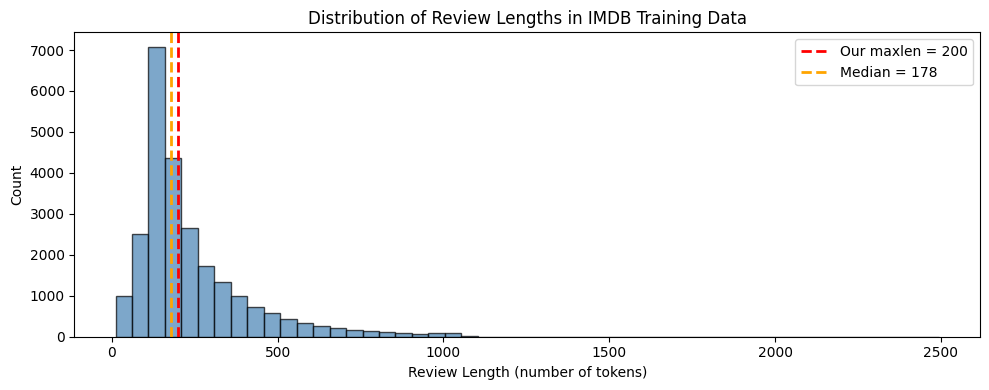

With maxlen=200, we fully capture 57.3% of reviews.
The rest will be truncated (longer reviews lose their tail).


In [ ]:
# Look at the distribution of review lengths
lengths = [len(x) for x in X_train_raw]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'Our maxlen = {MAX_LEN}')
ax.axvline(x=np.median(lengths), color='orange', linestyle='--', linewidth=2,
           label=f'Median = {np.median(lengths):.0f}')
ax.set_xlabel('Review Length (number of tokens)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Review Lengths in IMDB Training Data')
ax.legend()
plt.tight_layout()
plt.show()

pct_covered = np.mean([l <= MAX_LEN for l in lengths]) * 100
print(f"With maxlen={MAX_LEN}, we fully capture {pct_covered:.1f}% of reviews.")
print(f"The rest will be truncated (longer reviews lose their tail).")

In [ ]:
# Pad sequences
X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='post')
X_test = pad_sequences(X_test_raw, maxlen=MAX_LEN, padding='post')

print(f"Before padding: X_train is a list of {len(X_train_raw)} variable-length lists")
print(f"After padding:  X_train shape = {X_train.shape}")
print(f"                X_test shape  = {X_test.shape}")

Before padding: X_train is a list of 25000 variable-length lists
After padding:  X_train shape = (25000, 200)
                X_test shape  = (25000, 200)


In [ ]:
EMBEDDING_DIM

32

We've right now 25000 x 200 x 32

1. Flatenning: 25000 x (200 * 32) = 25000 * 6400
2. Global Average Pooling: 25000 * np.mean((200 * 32), axis=1)) # as tensor is rank 3

In [ ]:
# We've 25k sentences, Each sentence has 200 tokens, each token has 32 dimensional embedding.

# Flattening

In [ ]:
# ============================================================
# MODEL A: Embedding → Flatten → Dense → Output
# ============================================================

model_flatten = keras.Sequential([
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')   # Binary classification
])

model_flatten.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
model_flatten.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,189,189 (8.35 MB)

 Trainable params: 729,729 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,459,460 (5.57 MB)

In [ ]:
# Train both models
print("Training Model A (Flatten)...")
print("=" * 50)
history_flatten = model_flatten.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Training Model A (Flatten)...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7232 - loss: 0.5102 - val_accuracy: 0.8662 - val_loss: 0.3232
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9298 - loss: 0.1907 - val_accuracy: 0.8508 - val_loss: 0.3515
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9880 - loss: 0.0530 - val_accuracy: 0.8638 - val_loss: 0.3770
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9970 - loss: 0.0152 - val_accuracy: 0.8562 - val_loss: 0.4317
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9985 - loss: 0.0079 - val_accuracy: 0.8572 - val_loss: 0.4671


In [ ]:
# ============================================================
# MODEL B: Embedding → GlobalAveragePooling1D → Dense → Output
# ============================================================

model_gap = keras.Sequential([
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_gap.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
model_gap.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 966,533 (3.69 MB)

 Trainable params: 322,177 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,356 (2.46 MB)

In [ ]:
print("\nTraining Model B (Global Average Pooling)...")
print("=" * 50)
history_gap = model_gap.fit(
    X_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Training Model B (Global Average Pooling)...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6916 - loss: 0.6241 - val_accuracy: 0.8204 - val_loss: 0.4671
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8529 - loss: 0.3690 - val_accuracy: 0.8678 - val_loss: 0.3301
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8891 - loss: 0.2766 - val_accuracy: 0.8778 - val_loss: 0.3020
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9107 - loss: 0.2297 - val_accuracy: 0.8738 - val_loss: 0.2975
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9234 - loss: 0.2005 - val_accuracy: 0.8832 - val_loss: 0.2873


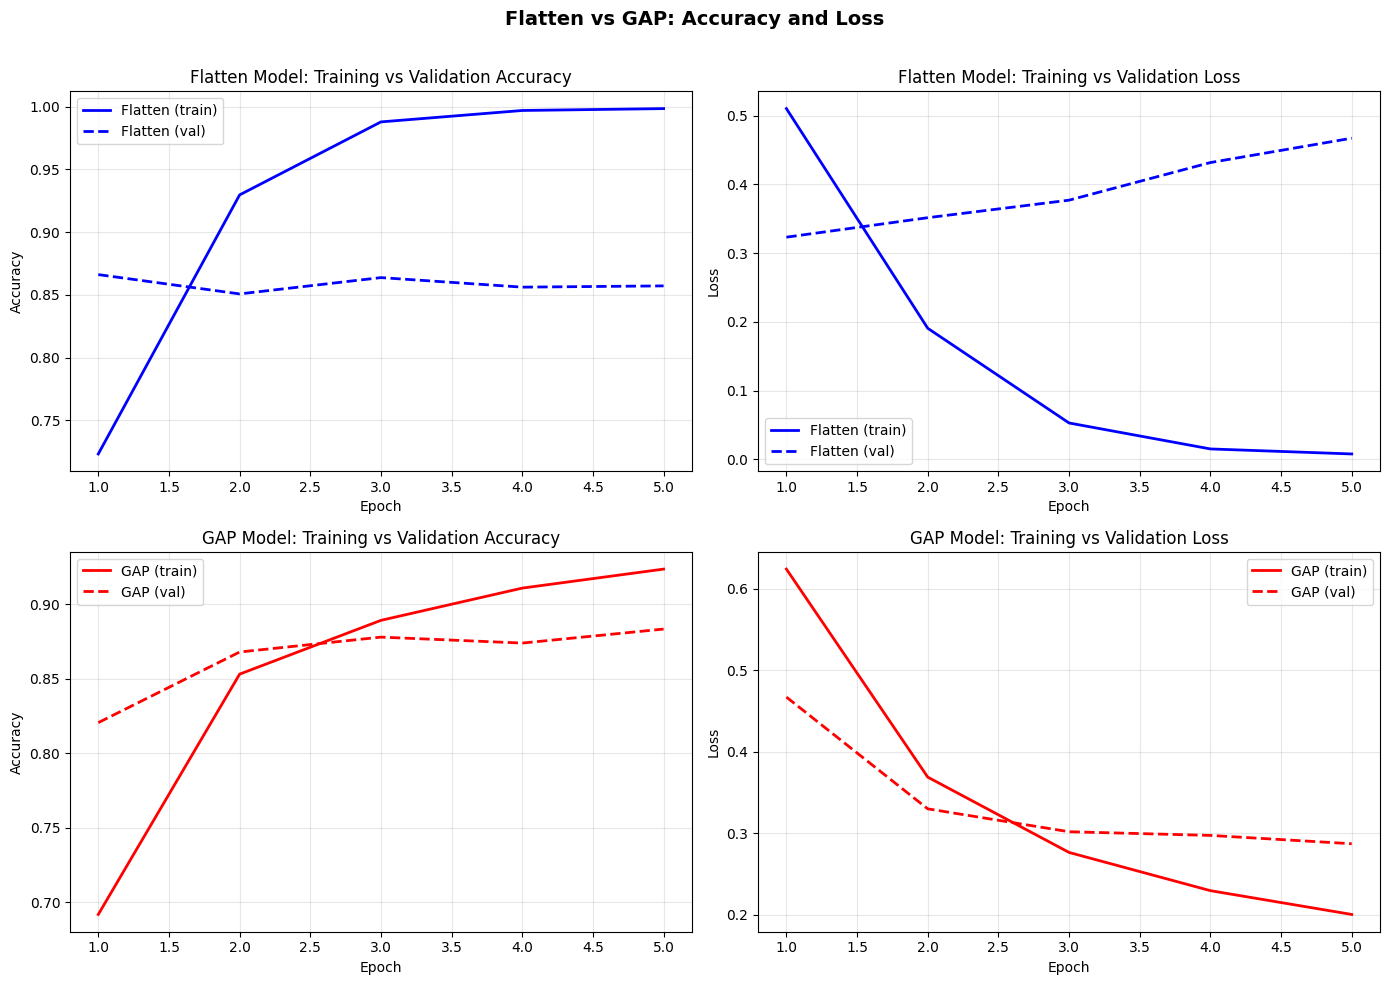

In [ ]:
# Compare training results in a 2x2 grid

epochs_flat = range(1, len(history_flatten.history['accuracy']) + 1)
epochs_gap = range(1, len(history_gap.history['accuracy']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Flatten Accuracy (top-left)
ax = axes[0, 0]
ax.plot(epochs_flat, history_flatten.history['accuracy'], 'b-', label='Flatten (train)', linewidth=2)
ax.plot(epochs_flat, history_flatten.history['val_accuracy'], 'b--', label='Flatten (val)', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Flatten Model: Training vs Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Flatten Loss (top-right)
ax = axes[0, 1]
ax.plot(epochs_flat, history_flatten.history['loss'], 'b-', label='Flatten (train)', linewidth=2)
ax.plot(epochs_flat, history_flatten.history['val_loss'], 'b--', label='Flatten (val)', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Flatten Model: Training vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 3) GAP Accuracy (bottom-left)
ax = axes[1, 0]
ax.plot(epochs_gap, history_gap.history['accuracy'], 'r-', label='GAP (train)', linewidth=2)
ax.plot(epochs_gap, history_gap.history['val_accuracy'], 'r--', label='GAP (val)', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('GAP Model: Training vs Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# 4) GAP Loss (bottom-right)
ax = axes[1, 1]
ax.plot(epochs_gap, history_gap.history['loss'], 'r-', label='GAP (train)', linewidth=2)
ax.plot(epochs_gap, history_gap.history['val_loss'], 'r--', label='GAP (val)', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GAP Model: Training vs Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Flatten vs GAP: Accuracy and Loss', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()